In [14]:
from PIL import Image, ImageDraw
import os
import random

def generate_final_dataset(num_images=10):
    # Data to pull from
    merchants = ["COFFEE SHOP", "TECH STORE", "BOOK HAVEN", "GROCERY MART", "PIZZA HUT", 
                 "PHARMACY PLUS", "ELECTRONICS WORLD", "BAKERY DELIGHT", "CLOTHING HUB", "STATIONERY CO"]
    
    os.makedirs('dummy_dataset', exist_ok=True)

    for i in range(num_images):
        img = Image.new('RGB', (600, 900), color='white')
        draw = ImageDraw.Draw(img)
        
        # Use modulo (%) to loop back to the start of the list if i > 10
        # This prevents IndexError forever!
        m_name = merchants[i % len(merchants)]
        price = round(random.uniform(5.0, 200.0), 2)
        
        draw.text((300, 50), m_name, fill='black', anchor='mt')
        draw.text((50, 150), f'Date: 04/22/2026', fill='black')
        draw.text((50, 200), f'Receipt ID: #100{i}', fill='black')
        draw.text((50, 300), f'TOTAL: ${price}', fill='black')
        
        img_name = f'dummy_dataset/receipt_{i+1}.jpg'
        img.save(img_name)
        print(f'Generated: {img_name}')

# ONLY CALL THIS ONE
generate_final_dataset(num_images=10)
        

Generated: dummy_dataset/receipt_1.jpg
Generated: dummy_dataset/receipt_2.jpg
Generated: dummy_dataset/receipt_3.jpg
Generated: dummy_dataset/receipt_4.jpg
Generated: dummy_dataset/receipt_5.jpg
Generated: dummy_dataset/receipt_6.jpg
Generated: dummy_dataset/receipt_7.jpg
Generated: dummy_dataset/receipt_8.jpg
Generated: dummy_dataset/receipt_9.jpg
Generated: dummy_dataset/receipt_10.jpg


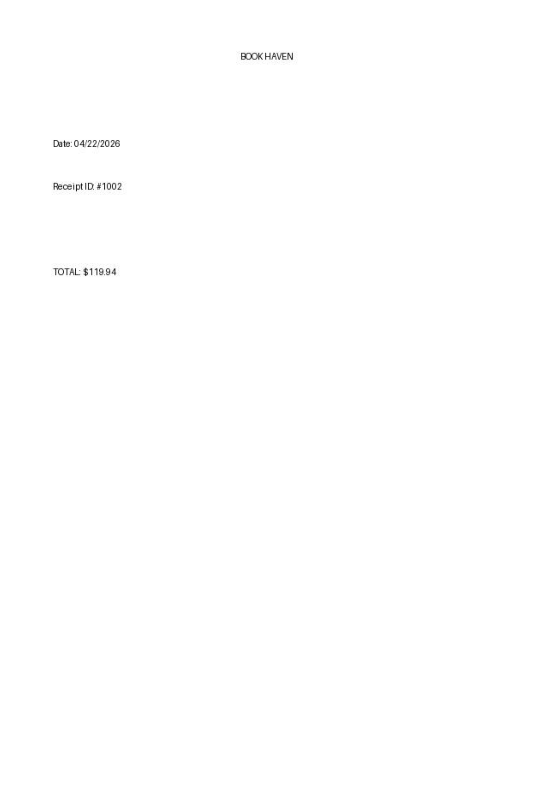

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Replace 'receipt1.jpg' with your filename
img = mpimg.imread('dummy_dataset/receipt_3.jpg')

plt.figure(figsize=(8, 10)) # Sets the display size 
plt.imshow(img)
plt.axis('off') # Hides the x and y axis numbers 
plt.show()

In [20]:
import shutil
import os

# Define names
source_dir = '/kaggle/working/dummy_dataset'
output_filename = '/kaggle/working/my_ocr_data'

# Check if the folder actually exists first
if os.path.exists(source_dir):
    # This creates 'my_ocr_data.zip'
    shutil.make_archive(output_filename, 'zip', source_dir)
    
    # Verify the zip file was created
    if os.path.exists(output_filename + '.zip'):
        print(f"SUCCESS: {output_filename}.zip is ready!")
    else:
        print("Error: Zip file was not created.")
else:
    print(f"Error: The folder {source_dir} does not exist. Run your generation script first!")

SUCCESS: /kaggle/working/my_ocr_data.zip is ready!


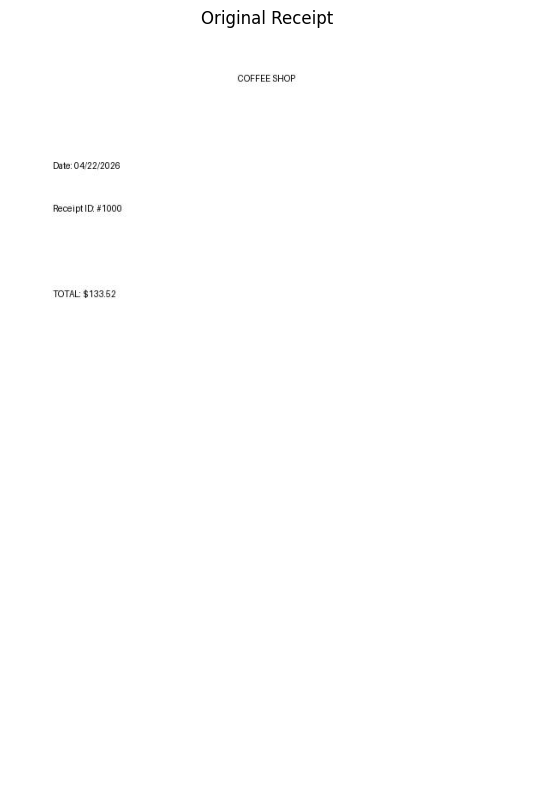

=== EXTRACTED TEXT ===
COFFEE SHOP:

Date: 04/22/2028

PeceiptiD #1000

TOTAL $1352



In [23]:
import pytesseract
from PIL import Image 
import matplotlib.pyplot as plt 

# CORRECTED: Point to an actual image file, NOT the zip file
img_path = '/kaggle/working/dummy_dataset/receipt_1.jpg' 

# Load and display 
img = Image.open(img_path) 
plt.figure(figsize=(8, 10)) 
plt.imshow(img) 
plt.title('Original Receipt') 
plt.axis('off') 
plt.show() 

# Extract text 
text = pytesseract.image_to_string(img) 
print('=== EXTRACTED TEXT ===') 
print(text)


In [24]:
import pandas as pd

# 1. Get detailed data including bounding boxes and confidence levels
# 'img' must be the PIL Image object from the previous cell
data = pytesseract.image_to_data(img, output_type='dict') 
df = pd.DataFrame(data) 

# 2. Filter out 'empty' detections and noise
# Tesseract often detects 'space' as a word with -1 confidence; we remove those
df = df[df['text'].str.strip() != ''] 
df = df[df['conf'] != -1] 

# 3. Print the results
print('=== CONFIDENCE SCORES ===') 
# head(20) shows the first 20 words detected
print(df[['text', 'conf']].head(20)) 

# 4. Summary Statistics
# This helps you meet the "Confidence scores calculated" deliverable
print(f"\nAverage Confidence: {df['conf'].mean():.1f}%") 
print(f"Total Words detected: {len(df)}")

=== CONFIDENCE SCORES ===
          text  conf
4       COFFEE    70
5        SHOP:    48
9        Date:    17
10  04/22/2028    17
14   PeceiptiD    60
15       #1000    90
19       TOTAL    95
20       $1352     0

Average Confidence: 49.6%
Total Words detected: 8


In [25]:
import easyocr

# Task 2.1: Initialize reader (downloads models first time)
# You only need to run this once in your session 
reader = easyocr.Reader(['en']) 
print('EasyOCR initialized!')

# Task 2.2: Extract Text with EasyOCR [cite: 66]
# Use the img_path we defined earlier (receipt_1.jpg) 
result = reader.readtext(img_path) 

# Display results with confidence levels 
print('=== EasyOCR RESULTS ===') 
for detection in result:
    bbox, text, confidence = detection # bbox is the coordinates, text is the string 
    print(f'Text: {text:20s} Confidence: {confidence:.2f}')

# Extract and join just the text to see the full document content 
extracted_text = ' '.join([detection[1] for detection in result])
print('\n=== FULL EXTRACTED TEXT ===')
print(extracted_text)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


EasyOCR initialized!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EasyOCR RESULTS ===
Text: COFFEE SHOP          Confidence: 0.99
Text: Date. 04/22/2026     Confidence: 0.31
Text: Receipt ID           Confidence: 0.68
Text: 100O                 Confidence: 0.27
Text: TOTAL: $133.52       Confidence: 0.87

=== FULL EXTRACTED TEXT ===
COFFEE SHOP Date. 04/22/2026 Receipt ID 100O TOTAL: $133.52


In [26]:
# Task 2.2: Extract Text with EasyOCR
# Make sure img_path is set to your dummy image: '/kaggle/working/dummy_dataset/receipt_1.jpg'
result = reader.readtext(img_path) 

print('=== EasyOCR RESULTS ===') 
# Looping through detections to show specific word accuracy
for detection in result:
    bbox, text, confidence = detection
    # Formatting to keep the columns aligned
    print(f'Text: {text:20s} | Confidence: {confidence:.2f}')

# Part of the lab: Extracting a single clean string of all detected text
extracted_text = ' '.join([detection[1] for detection in result]) 
print('\n=== FULL EXTRACTED TEXT ===') 
print(extracted_text)

=== EasyOCR RESULTS ===
Text: COFFEE SHOP          | Confidence: 0.99
Text: Date. 04/22/2026     | Confidence: 0.31
Text: Receipt ID           | Confidence: 0.68
Text: 100O                 | Confidence: 0.27
Text: TOTAL: $133.52       | Confidence: 0.87

=== FULL EXTRACTED TEXT ===
COFFEE SHOP Date. 04/22/2026 Receipt ID 100O TOTAL: $133.52


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


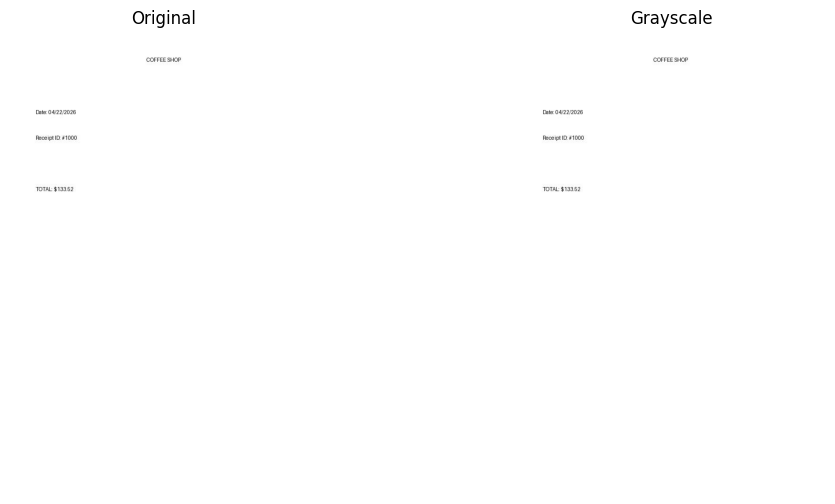

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# UPDATE: Point to your generated dummy image
img_path = '/kaggle/working/dummy_dataset/receipt_1.jpg'

# Load image using OpenCV
img = cv2.imread(img_path)

# Convert to grayscale
# This removes color noise and helps the OCR focus on text shapes 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display comparison using Matplotlib subplots [cite: 71, 74]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Show original (Convert BGR to RGB because OpenCV loads images in BGR) [cite: 75]
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

# Show Grayscale version
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

plt.show()

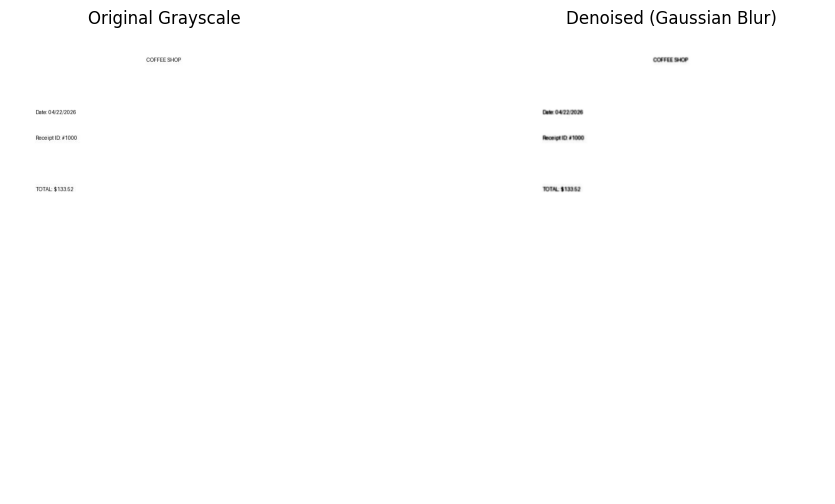

In [28]:
# Task 3.2: Noise Reduction (Gaussian Blur)
# (5, 5) is the kernel size; increasing this makes the image blurrier
denoised = cv2.GaussianBlur(gray, (5, 5), 0) 

# Display comparison to verify noise reduction
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original Grayscale from previous task
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

# Denoised version
axes[1].imshow(denoised, cmap='gray')
axes[1].set_title('Denoised (Gaussian Blur)')
axes[1].axis('off')

plt.show()

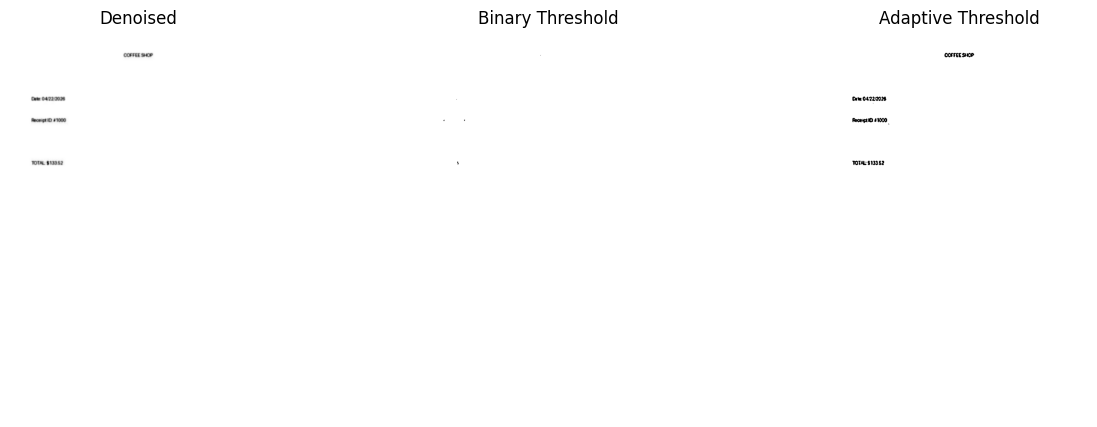

In [29]:
# Task 3.3: Thresholding
# Binary thresholding
_, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY) 

# Adaptive thresholding
adaptive = cv2.adaptiveThreshold(
    denoised, 255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2
) 

# Display Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(denoised, cmap='gray') 
axes[0].set_title('Denoised') 
axes[1].imshow(binary, cmap='gray') 
axes[1].set_title('Binary Threshold') 
axes[2].imshow(adaptive, cmap='gray') 
axes[2].set_title('Adaptive Threshold') 

for ax in axes: 
    ax.axis('off') 
plt.show()

In [30]:
# Task 4.1: Before vs After Comparison
# OCR on original image
text_original = pytesseract.image_to_string( 
    Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) 
) 

# OCR on preprocessed image (using the 'adaptive' variable from Task 3.3)
text_preprocessed = pytesseract.image_to_string( 
    Image.fromarray(adaptive) 
) 

print('=== ORIGINAL IMAGE ===') 
print(text_original) 
print(f'Characters: {len(text_original)}') 

print('\n=== PREPROCESSED IMAGE ===') 
print(text_preprocessed) 
print(f'Characters: {len(text_preprocessed)}') 

# Calculating the improvement
improvement = len(text_preprocessed) - len(text_original) 
print(f'\nImprovement: +{improvement} chars') 

# Calculate improvement as a percentage of the original text length
percentage = (improvement / max(len(text_original), 1)) * 100
print(f'Percentage: {percentage:.1f}%')

=== ORIGINAL IMAGE ===
COFFEE SHOP:

Date: 04/22/2026

PeceiptiD #1000

TOTAL $13352

Characters: 63

=== PREPROCESSED IMAGE ===
Gre 042272008

Rrceigti0 51000

TOTAL S13382

Characters: 46

Improvement: +-17 chars
Percentage: -27.0%


In [31]:
def compare_ocr_methods(image_path):
    # 1. Load and Preprocess
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Adaptive Thresholding creates the best version for Tesseract
    thresh = cv2.adaptiveThreshold(
        denoised, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    # 2. Tesseract OCR (using preprocessed image)
    tess_text = pytesseract.image_to_string(Image.fromarray(thresh))
    
    # 3. EasyOCR (using original path as it handles its own internal scaling)
    easy_result = reader.readtext(image_path)
    easy_text = ' '.join([r[1] for r in easy_result])
    
    return tess_text, easy_text

# Test function on one of your dummy images
tess, easy = compare_ocr_methods(img_path)
print(f'Tesseract Detected: {len(tess)} characters')
print(f'EasyOCR Detected:   {len(easy)} characters')

Tesseract Detected: 46 characters
EasyOCR Detected:   59 characters


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [36]:

!git init
!git config --global user.email "nayyab964@gmail.com"
!git config --global user.name "nayyab964-design"
!git add .
!git commit -m "Add Lab 5 OCR project"

Reinitialized existing Git repository in /kaggle/working/.git/
[master 2be183a] Add Lab 5 OCR project
 1 file changed, 2 insertions(+), 2 deletions(-)
